In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.io import arff
from sklearn.model_selection import train_test_split, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

In [58]:
data, meta = arff.loadarff("Autism-Adult-Data.arff")
df = pd.DataFrame(data)
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,b'1',b'1',b'1',b'1',b'0',b'0',b'1',b'1',b'0',b'0',...,b'f',b'White-European',b'no',b'no',b'United States',b'no',6.0,b'18 and more',b'Self',b'NO'
1,b'1',b'1',b'0',b'1',b'0',b'0',b'0',b'1',b'0',b'1',...,b'm',b'Latino',b'no',b'yes',b'Brazil',b'no',5.0,b'18 and more',b'Self',b'NO'
2,b'1',b'1',b'0',b'1',b'1',b'0',b'1',b'1',b'1',b'1',...,b'm',b'Latino',b'yes',b'yes',b'Spain',b'no',8.0,b'18 and more',b'Parent',b'YES'
3,b'1',b'1',b'0',b'1',b'0',b'0',b'1',b'1',b'0',b'1',...,b'f',b'White-European',b'no',b'yes',b'United States',b'no',6.0,b'18 and more',b'Self',b'NO'
4,b'1',b'0',b'0',b'0',b'0',b'0',b'0',b'1',b'0',b'0',...,b'f',b'?',b'no',b'no',b'Egypt',b'no',2.0,b'18 and more',b'?',b'NO'


In [59]:
for col in df.select_dtypes(include='object').columns:
    if df[col].notna().any() and isinstance(df[col].dropna().iloc[0], bytes):
        df[col] = df[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,United States,no,6.0,18 and more,Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5.0,18 and more,Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8.0,18 and more,Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,United States,no,6.0,18 and more,Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2.0,18 and more,?,NO


In [60]:
df.to_csv("New Autism.csv", index=False)

In [61]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 704 entries, 0 to 703
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   A1_Score         704 non-null    object 
 1   A2_Score         704 non-null    object 
 2   A3_Score         704 non-null    object 
 3   A4_Score         704 non-null    object 
 4   A5_Score         704 non-null    object 
 5   A6_Score         704 non-null    object 
 6   A7_Score         704 non-null    object 
 7   A8_Score         704 non-null    object 
 8   A9_Score         704 non-null    object 
 9   A10_Score        704 non-null    object 
 10  age              702 non-null    float64
 11  gender           704 non-null    object 
 12  ethnicity        704 non-null    object 
 13  jundice          704 non-null    object 
 14  austim           704 non-null    object 
 15  contry_of_res    704 non-null    object 
 16  used_app_before  704 non-null    object 
 17  result          

In [62]:
for i in range(1, 11):
    col_name = f'A{i}_Score'
    if col_name in df.columns:
        df[col_name] = pd.to_numeric(df[col_name], errors='coerce').astype(int)
df['age'] = df['age'].fillna(df['age'].median()).astype(int)
df['result'] = df['result'].astype(int)

In [63]:
df.head()

,A1_Score,A2_Score,A3_Score,A4_Score,A5_Score,A6_Score,A7_Score,A8_Score,A9_Score,A10_Score,...,gender,ethnicity,jundice,austim,contry_of_res,used_app_before,result,age_desc,relation,Class/ASD
0,1,1,1,1,0,0,1,1,0,0,...,f,White-European,no,no,United States,no,6,18 and more,Self,NO
1,1,1,0,1,0,0,0,1,0,1,...,m,Latino,no,yes,Brazil,no,5,18 and more,Self,NO
2,1,1,0,1,1,0,1,1,1,1,...,m,Latino,yes,yes,Spain,no,8,18 and more,Parent,YES
3,1,1,0,1,0,0,1,1,0,1,...,f,White-European,no,yes,United States,no,6,18 and more,Self,NO
4,1,0,0,0,0,0,0,1,0,0,...,f,?,no,no,Egypt,no,2,18 and more,?,NO


In [64]:
df['ethnicity'] = df['ethnicity'].replace('?', 'unknown')
df['relation'] = df['relation'].replace('?', 'unknown')

In [65]:
x = df.drop(['Class/ASD', 'result'], axis=1)
y = df['Class/ASD']

y = y.map({'NO': 0, 'YES': 1})

cat_col = x.select_dtypes(include='object').columns
x = pd.get_dummies(x, columns=cat_col, drop_first=True)

## RandomForestClassifier

              precision    recall  f1-score   support

           0       0.96      1.00      0.98       154
           1       1.00      0.88      0.94        58

    accuracy                           0.97       212
   macro avg       0.98      0.94      0.96       212
weighted avg       0.97      0.97      0.97       212



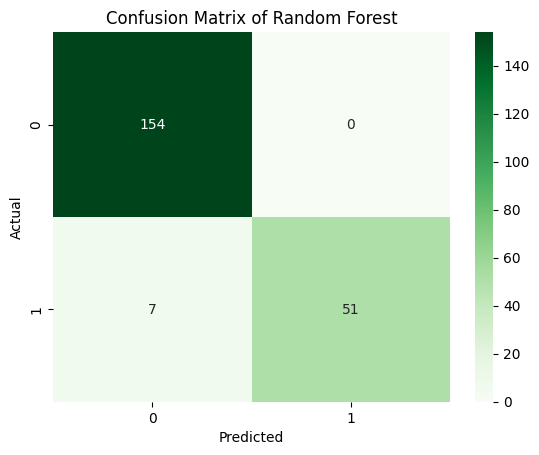

In [66]:
x_tr, x_ts, y_tr, y_ts = train_test_split(x, y, test_size=0.3, random_state=43)

rf = RandomForestClassifier()
model = rf.fit(x_tr, y_tr)
y_pred = model.predict(x_ts)
print(classification_report(y_ts, y_pred))
cm = confusion_matrix(y_ts, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix of Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [67]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

rf_classifier = RandomForestClassifier(random_state=42)

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

for train_index, test_index in kf.split(x):
    x_train_fold, x_test_fold = x.iloc[train_index], x.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    rf_classifier.fit(x_train_fold, y_train_fold)
    y_pred_fold = rf_classifier.predict(x_test_fold)

    accuracy_scores.append(accuracy_score(y_test_fold, y_pred_fold))
    precision_scores.append(precision_score(y_test_fold, y_pred_fold))
    recall_scores.append(recall_score(y_test_fold, y_pred_fold))
    f1_scores.append(f1_score(y_test_fold, y_pred_fold))

print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Average Precision: {np.mean(precision_scores):.4f}")
print(f"Average Recall: {np.mean(recall_scores):.4f}")
print(f"Average F1-Score: {np.mean(f1_scores):.4f}")

Average Accuracy: 0.9573
Average Precision: 0.9612
Average Recall: 0.8769
Average F1-Score: 0.9147


## SVM

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       154
           1       1.00      1.00      1.00        58

    accuracy                           1.00       212
   macro avg       1.00      1.00      1.00       212
weighted avg       1.00      1.00      1.00       212



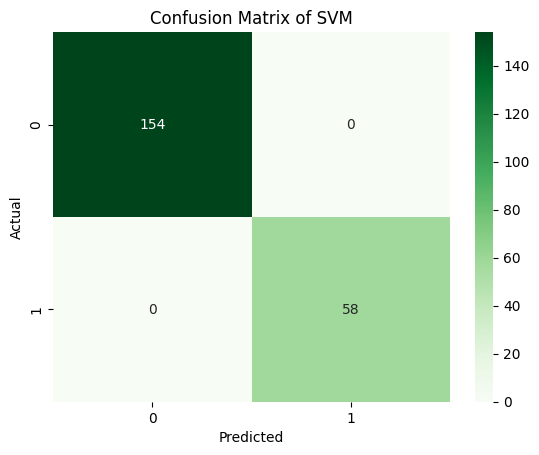

In [68]:
model = SVC(kernel="linear", random_state=43)
model = model.fit(x_tr, y_tr)
y_pred = model.predict(x_ts)
print(classification_report(y_ts, y_pred))
cm = confusion_matrix(y_ts, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix of SVM')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [69]:
kf = KFold(n_splits=10, shuffle=True, random_state=42)

svm_classifier = SVC(kernel="linear", random_state=43)

accuracy_scores = []
precision_scores = []
recall_scores = []
f1_scores = []

last_y_test_fold = None
last_y_pred_fold = None

for train_index, test_index in kf.split(x):
    x_train_fold, x_test_fold = x.iloc[train_index], x.iloc[test_index]
    y_train_fold, y_test_fold = y.iloc[train_index], y.iloc[test_index]

    svm_classifier.fit(x_train_fold, y_train_fold)
    y_pred_fold = svm_classifier.predict(x_test_fold)

    accuracy_scores.append(accuracy_score(y_test_fold, y_pred_fold))
    precision_scores.append(precision_score(y_test_fold, y_pred_fold, zero_division=0))
    recall_scores.append(recall_score(y_test_fold, y_pred_fold, zero_division=0))
    f1_scores.append(f1_score(y_test_fold, y_pred_fold, zero_division=0))

    last_y_test_fold = y_test_fold
    last_y_pred_fold = y_pred_fold

print(f"Average Accuracy: {np.mean(accuracy_scores):.4f}")
print(f"Average Precision: {np.mean(precision_scores):.4f}")
print(f"Average Recall: {np.mean(recall_scores):.4f}")
print(f"Average F1-Score: {np.mean(f1_scores):.4f}")

Average Accuracy: 1.0000
Average Precision: 1.0000
Average Recall: 1.0000
Average F1-Score: 1.0000


              precision    recall  f1-score   support

           0       0.90      0.79      0.84       154
           1       0.58      0.78      0.66        58

    accuracy                           0.78       212
   macro avg       0.74      0.78      0.75       212
weighted avg       0.81      0.78      0.79       212



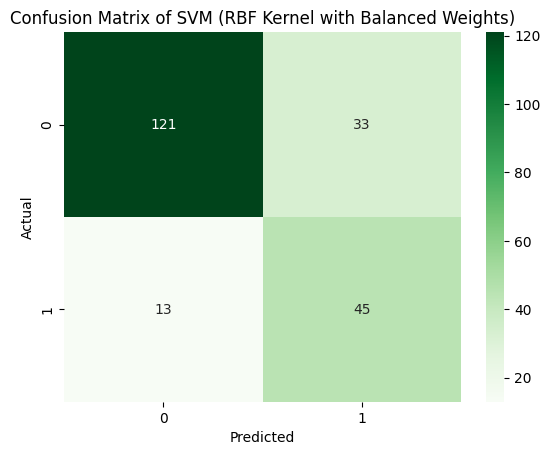

In [70]:
model = SVC(kernel="rbf", random_state=43, class_weight='balanced')
model = model.fit(x_tr, y_tr)
y_pred = model.predict(x_ts)
print(classification_report(y_ts, y_pred))
cm = confusion_matrix(y_ts, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix of SVM (RBF Kernel with Balanced Weights)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

              precision    recall  f1-score   support

           0       0.73      0.45      0.56       154
           1       0.28      0.57      0.38        58

    accuracy                           0.48       212
   macro avg       0.51      0.51      0.47       212
weighted avg       0.61      0.48      0.51       212



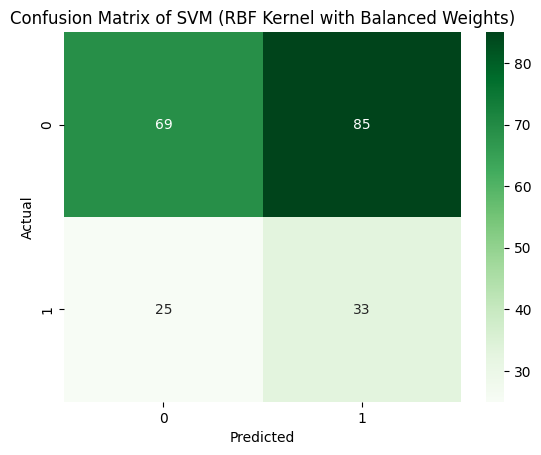

In [71]:
model = SVC(kernel="sigmoid", random_state=43, class_weight='balanced')
model = model.fit(x_tr, y_tr)
y_pred = model.predict(x_ts)
print(classification_report(y_ts, y_pred))
cm = confusion_matrix(y_ts, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix of SVM (RBF Kernel with Balanced Weights)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## MLP

              precision    recall  f1-score   support

           0       0.97      0.97      0.97       154
           1       0.92      0.93      0.92        58

    accuracy                           0.96       212
   macro avg       0.94      0.95      0.95       212
weighted avg       0.96      0.96      0.96       212



c:\Users\MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


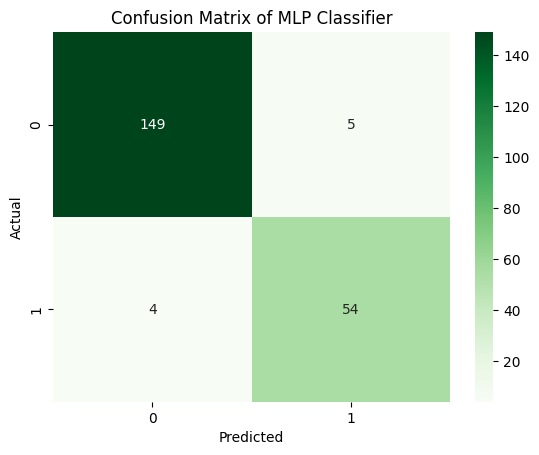

In [72]:
mlp_classifier = MLPClassifier(random_state=42, max_iter=300)
mlp_classifier.fit(x_tr, y_tr)

y_pred_mlp = mlp_classifier.predict(x_ts)

print(classification_report(y_ts, y_pred_mlp))

cm_mlp = confusion_matrix(y_ts, y_pred_mlp)
sns.heatmap(cm_mlp, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix of MLP Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Decision Tree

Decision Tree Classifier Accuracy: 0.9057

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.95      0.94       155
           1       0.86      0.77      0.81        57

    accuracy                           0.91       212
   macro avg       0.89      0.86      0.88       212
weighted avg       0.90      0.91      0.90       212



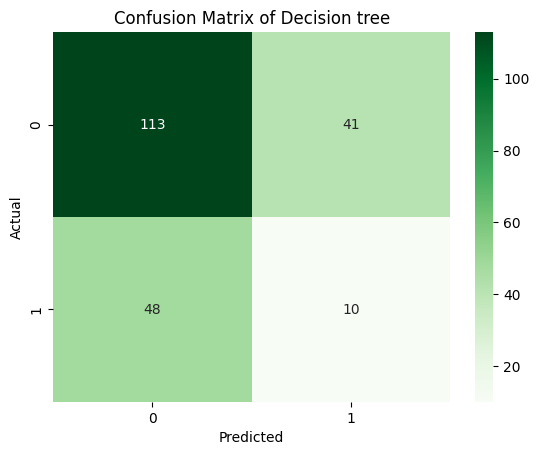

In [73]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

decision_tree_model = DecisionTreeClassifier(random_state=42)
decision_tree_model.fit(x_train, y_train)

y_pred = decision_tree_model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred)

print(f"Decision Tree Classifier Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(report)

cm = confusion_matrix(y_ts, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix of Decision tree')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## XGBoost

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       155
           1       0.93      0.98      0.96        57

    accuracy                           0.98       212
   macro avg       0.96      0.98      0.97       212
weighted avg       0.98      0.98      0.98       212



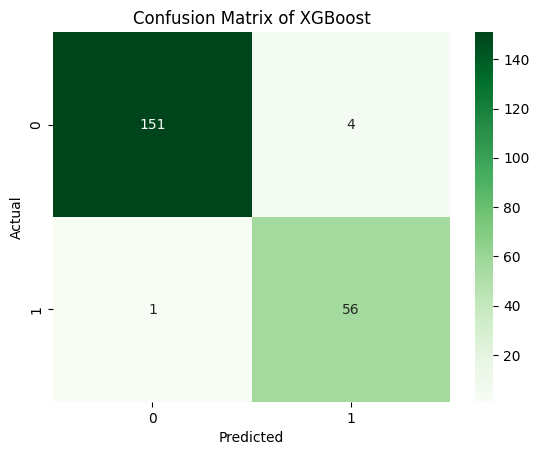

In [74]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=42)

xgb_model = XGBClassifier(random_state=42, eval_metric='logloss')
xgb_model.fit(x_train, y_train)

y_pred = xgb_model.predict(x_test)

print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix of XGBoost')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## Ensemble

In [75]:
rf_clf = RandomForestClassifier(random_state=43)
svm_clf = SVC(kernel='linear', random_state=43)
mlp_clf = MLPClassifier(random_state=42, max_iter=500)
dt_clf = DecisionTreeClassifier(random_state=43)
xgb_clf = XGBClassifier(random_state=43, eval_metric='logloss', use_label_encoder=False)

rf_clf.fit(x_tr, y_tr)
svm_clf.fit(x_tr, y_tr)
mlp_clf.fit(x_tr, y_tr)
dt_clf.fit(x_tr, y_tr)
xgb_clf.fit(x_tr, y_tr)

c:\Users\MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:14:49] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

              precision    recall  f1-score   support

           0       0.97      1.00      0.98       154
           1       1.00      0.91      0.95        58

    accuracy                           0.98       212
   macro avg       0.98      0.96      0.97       212
weighted avg       0.98      0.98      0.98       212



c:\Users\MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
c:\Users\MSI\AppData\Local\Programs\Python\Python313\Lib\site-packages\xgboost\training.py:199: UserWarning: [12:14:50] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


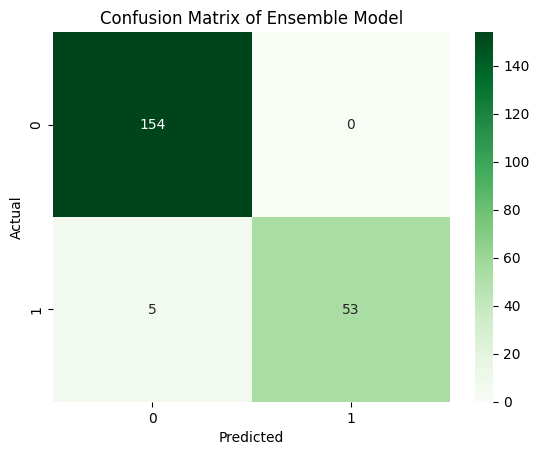

In [76]:
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

estimators = [
    ('random_forest', rf_clf),
    ('svm_linear', svm_clf),
    ('mlp', mlp_clf),
    ('decision_tree', dt_clf),
    ('xgboost', xgb_clf)
]

voting_clf = VotingClassifier(estimators=estimators, voting='hard')

voting_clf.fit(x_tr, y_tr)

y_pred_ensemble = voting_clf.predict(x_ts)

print(classification_report(y_ts, y_pred_ensemble))

cm_ensemble = confusion_matrix(y_ts, y_pred_ensemble)
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Greens')
plt.title('Confusion Matrix of Ensemble Model')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Spiking Neural Network (SNN)

In [77]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
import snntorch as snn
from snntorch import surrogate
from snntorch import functional as SF

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: NVIDIA GeForce RTX 5070


In [78]:
x_tensor = torch.tensor(x.astype(float).values, dtype=torch.float32).to(device)
y_tensor = torch.tensor(y.values, dtype=torch.long).to(device)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x_tensor.cpu())
x_scaled_tensor = torch.tensor(x_scaled, dtype=torch.float32).to(device)

x_train_snn, x_test_snn, y_train_snn, y_test_snn = train_test_split(
    x_scaled_tensor.cpu(), y_tensor.cpu(), test_size=0.2, random_state=42
)
x_train_snn = x_train_snn.to(device)
x_test_snn = x_test_snn.to(device)
y_train_snn = y_train_snn.to(device)
y_test_snn = y_test_snn.to(device)

print(f"Training samples: {len(x_train_snn)}")
print(f"Testing samples: {len(x_test_snn)}")
print(f"Input features: {x_train_snn.shape[1]}")
print(f"Number of classes: {len(torch.unique(y_tensor))}")

Training samples: 563
Testing samples: 141
Input features: 97
Number of classes: 2


## Rate Coding Encoder

In [79]:
def rate_encode(data, num_steps):
    device = data.device
    min_val = data.min()
    max_val = data.max()
    normalized_data = (data - min_val) / (max_val - min_val + 1e-8)
    
    num_samples, num_features = normalized_data.shape
    spike_trains = torch.zeros(num_steps, num_samples, num_features, dtype=torch.float32, device=device)
    
    for t in range(num_steps):
        spike_trains[t] = (torch.rand(num_samples, num_features, device=device) < normalized_data).float()
    
    return spike_trains

num_steps = 50
x_train_rate = rate_encode(x_train_snn, num_steps).permute(1, 0, 2)
x_test_rate = rate_encode(x_test_snn, num_steps).permute(1, 0, 2)

print(f"Rate coded training shape: {x_train_rate.shape}")
print(f"Rate coded testing shape: {x_test_rate.shape}")

Rate coded training shape: torch.Size([563, 50, 97])
Rate coded testing shape: torch.Size([141, 50, 97])


## Population Coding Encoder

In [80]:
def population_encode(data, num_neurons, num_steps):
    device = data.device
    min_val = data.min()
    max_val = data.max()
    normalized_data = (data - min_val) / (max_val - min_val + 1e-8)
    
    num_samples, num_features = normalized_data.shape
    centers = torch.linspace(0, 1, num_neurons, device=device)
    sigma = 1.0 / (2 * num_neurons)
    
    encoded = torch.zeros(num_samples, num_features * num_neurons, device=device)
    
    for i, center in enumerate(centers):
        gaussian_response = torch.exp(-((normalized_data - center) ** 2) / (2 * sigma ** 2))
        encoded[:, i::num_neurons] = gaussian_response
    
    spike_trains = torch.zeros(num_steps, num_samples, num_features * num_neurons, device=device)
    for t in range(num_steps):
        spike_trains[t] = (torch.rand_like(encoded) < encoded).float()
    
    return spike_trains

num_neurons_per_feature = 5
x_train_pop = population_encode(x_train_snn, num_neurons_per_feature, num_steps).permute(1, 0, 2)
x_test_pop = population_encode(x_test_snn, num_neurons_per_feature, num_steps).permute(1, 0, 2)

print(f"Population coded training shape: {x_train_pop.shape}")
print(f"Population coded testing shape: {x_test_pop.shape}")

Population coded training shape: torch.Size([563, 50, 485])
Population coded testing shape: torch.Size([141, 50, 485])


## LIF Neuron Model

In [81]:
class LIFNeuron(nn.Module):
    def __init__(self, beta, threshold=1.0, surrogate_grad=surrogate.atan()):
        super().__init__()
        self.beta = beta
        self.threshold = threshold
        self.surrogate_grad = surrogate_grad
    
    def forward(self, cur_in, mem):
        mem = self.beta * mem + cur_in
        spk = self.surrogate_grad(mem - self.threshold)
        mem = mem * (1 - spk)
        return spk, mem

## Double Decaying Model

In [82]:
class DoubleDecayingSynapse(nn.Module):
    def __init__(self, tau_rise=5.0, tau_fall=20.0):
        super().__init__()
        self.tau_rise = tau_rise
        self.tau_fall = tau_fall
        self.alpha_rise = torch.exp(torch.tensor(-1.0/tau_rise))
        self.alpha_fall = torch.exp(torch.tensor(-1.0/tau_fall))
    
    def forward(self, spk_in, syn_rise, syn_fall):
        syn_rise = self.alpha_rise * syn_rise + spk_in
        syn_fall = self.alpha_fall * syn_fall + spk_in
        current = syn_fall - syn_rise
        return current, syn_rise, syn_fall

In [83]:
class SNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, beta=0.9):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.lif1 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.lif2 = snn.Leaky(beta=beta)
    
    def forward(self, x):
        num_steps = x.size(0)
        batch_size = x.size(1)
        
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        
        spk2_rec = []
        mem2_rec = []
        
        for step in range(num_steps):
            cur1 = self.fc1(x[step])
            spk1, mem1 = self.lif1(cur1, mem1)
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)
        
        return torch.stack(spk2_rec), torch.stack(mem2_rec)

## Surrogate Gradient Descent with Rate Coding

In [84]:
model_surrogate_rate = SNN(input_size=x_train_snn.shape[1], hidden_size=128, output_size=2, beta=0.9).to(device)
optimizer = torch.optim.Adam(model_surrogate_rate.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

num_epochs = 20
for epoch in range(num_epochs):
    total_loss = 0
    for i in range(len(x_train_rate)):
        optimizer.zero_grad()
        x_sample = x_train_rate[i].unsqueeze(1)
        y_sample = y_train_snn[i].unsqueeze(0)
        
        spk_rec, mem_rec = model_surrogate_rate(x_sample)
        output = mem_rec.sum(dim=0)
        loss = loss_fn(output, y_sample)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {total_loss/len(x_train_rate):.4f}')

Epoch 10, Loss: 0.2003
Epoch 20, Loss: 0.1372


In [85]:
model_surrogate_rate.eval()
predictions = []
with torch.no_grad():
    for i in range(len(x_test_rate)):
        x_sample = x_test_rate[i].unsqueeze(1)
        spk_rec, mem_rec = model_surrogate_rate(x_sample)
        output = mem_rec.sum(dim=0)
        pred = output.argmax(dim=1)
        predictions.append(pred.item())

predictions = np.array(predictions)
accuracy_surrogate_rate = accuracy_score(y_test_snn.cpu(), predictions)
precision_surrogate_rate = precision_score(y_test_snn.cpu(), predictions, average='weighted', zero_division=0)
recall_surrogate_rate = recall_score(y_test_snn.cpu(), predictions, average='weighted', zero_division=0)
f1_surrogate_rate = f1_score(y_test_snn.cpu(), predictions, average='weighted', zero_division=0)

print(f'Accuracy: {accuracy_surrogate_rate:.4f}')
print(f'Precision: {precision_surrogate_rate:.4f}')
print(f'Recall: {recall_surrogate_rate:.4f}')
print(f'F1-Score: {f1_surrogate_rate:.4f}')

Accuracy: 0.8369
Precision: 0.8657
Recall: 0.8369
F1-Score: 0.8440


## Surrogate Gradient Descent with Population Coding

In [86]:
model_surrogate_pop = SNN(input_size=x_train_pop.shape[2], hidden_size=128, output_size=2, beta=0.9).to(device)
optimizer = torch.optim.Adam(model_surrogate_pop.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

num_epochs = 20
for epoch in range(num_epochs):
    total_loss = 0
    for i in range(len(x_train_pop)):
        optimizer.zero_grad()
        x_sample = x_train_pop[i].unsqueeze(1)
        y_sample = y_train_snn[i].unsqueeze(0)
        
        spk_rec, mem_rec = model_surrogate_pop(x_sample)
        output = mem_rec.sum(dim=0)
        loss = loss_fn(output, y_sample)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if (epoch + 1) % 5 == 0:
        print(f'Epoch {epoch+1}, Loss: {total_loss/len(x_train_pop):.4f}')

Epoch 5, Loss: 0.2718
Epoch 10, Loss: 0.2424
Epoch 15, Loss: 0.1759
Epoch 20, Loss: 0.1837


In [87]:
model_surrogate_pop.eval()
predictions = []
with torch.no_grad():
    for i in range(len(x_test_pop)):
        x_sample = x_test_pop[i].unsqueeze(1)
        spk_rec, mem_rec = model_surrogate_pop(x_sample)
        output = mem_rec.sum(dim=0)
        pred = output.argmax(dim=1)
        predictions.append(pred.item())

predictions = np.array(predictions)
accuracy_surrogate_pop = accuracy_score(y_test_snn.cpu(), predictions)
precision_surrogate_pop = precision_score(y_test_snn.cpu(), predictions, average='weighted', zero_division=0)
recall_surrogate_pop = recall_score(y_test_snn.cpu(), predictions, average='weighted', zero_division=0)
f1_surrogate_pop = f1_score(y_test_snn.cpu(), predictions, average='weighted', zero_division=0)

print(f'Accuracy: {accuracy_surrogate_pop:.4f}')
print(f'Precision: {precision_surrogate_pop:.4f}')
print(f'Recall: {recall_surrogate_pop:.4f}')
print(f'F1-Score: {f1_surrogate_pop:.4f}')

Accuracy: 0.9433
Precision: 0.9470
Recall: 0.9433
F1-Score: 0.9442


## STDP Training with Rate Coding

In [88]:
class SNNWithSTDP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, beta=0.9, lr_stdp=0.01):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size, bias=False)
        self.lif1 = snn.Leaky(beta=beta)
        self.fc2 = nn.Linear(hidden_size, output_size, bias=False)
        self.lif2 = snn.Leaky(beta=beta)
        self.lr_stdp = lr_stdp
        
    def stdp_update(self, w, pre_spike, post_spike, a_plus=0.01, a_minus=0.01):
        dw = torch.zeros_like(w)
        if pre_spike.sum() > 0 and post_spike.sum() > 0:
            dw = a_plus * torch.outer(post_spike, pre_spike)
            dw -= a_minus * torch.outer(post_spike, pre_spike)
        return w + self.lr_stdp * dw
    
    def forward(self, x, apply_stdp=False):
        num_steps = x.size(0)
        batch_size = x.size(1)
        
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        
        spk2_rec = []
        mem2_rec = []
        
        for step in range(num_steps):
            cur1 = self.fc1(x[step])
            spk1, mem1 = self.lif1(cur1, mem1)
            
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif2(cur2, mem2)
            
            if apply_stdp and step > 0:
                with torch.no_grad():
                    self.fc1.weight.data = self.stdp_update(self.fc1.weight.data, x[step].squeeze(), spk1.squeeze())
                    self.fc2.weight.data = self.stdp_update(self.fc2.weight.data, spk1.squeeze(), spk2.squeeze())
            
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)
        
        return torch.stack(spk2_rec), torch.stack(mem2_rec)

model_stdp_rate = SNNWithSTDP(input_size=x_train_snn.shape[1], hidden_size=128, output_size=2, beta=0.9, lr_stdp=0.001).to(device)
optimizer = torch.optim.Adam(model_stdp_rate.parameters(), lr=0.0001)
loss_fn = nn.CrossEntropyLoss()

num_epochs = 50
for epoch in range(num_epochs):
    total_loss = 0
    for i in range(len(x_train_rate)):
        optimizer.zero_grad()
        x_sample = x_train_rate[i].unsqueeze(1)
        y_sample = y_train_snn[i].unsqueeze(0)
        
        spk_rec, mem_rec = model_stdp_rate(x_sample, apply_stdp=True)
        output = mem_rec.sum(dim=0)
        loss = loss_fn(output, y_sample)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {total_loss/len(x_train_rate):.4f}')

Epoch 10, Loss: 0.1365
Epoch 20, Loss: 0.0282
Epoch 30, Loss: 0.0071
Epoch 40, Loss: 0.0028
Epoch 50, Loss: 0.0116


In [89]:
model_stdp_rate.eval()
predictions = []
with torch.no_grad():
    for i in range(len(x_test_rate)):
        x_sample = x_test_rate[i].unsqueeze(1)
        spk_rec, mem_rec = model_stdp_rate(x_sample, apply_stdp=False)
        output = mem_rec.sum(dim=0)
        pred = output.argmax(dim=1)
        predictions.append(pred.item())

predictions = np.array(predictions)
accuracy_stdp_rate = accuracy_score(y_test_snn.cpu(), predictions)
precision_stdp_rate = precision_score(y_test_snn.cpu(), predictions, average='weighted', zero_division=0)
recall_stdp_rate = recall_score(y_test_snn.cpu(), predictions, average='weighted', zero_division=0)
f1_stdp_rate = f1_score(y_test_snn.cpu(), predictions, average='weighted', zero_division=0)

print(f'Accuracy: {accuracy_stdp_rate:.4f}')
print(f'Precision: {precision_stdp_rate:.4f}')
print(f'Recall: {recall_stdp_rate:.4f}')
print(f'F1-Score: {f1_stdp_rate:.4f}')

Accuracy: 0.8723
Precision: 0.8690
Recall: 0.8723
F1-Score: 0.8698


## STDP Training with Population Coding

In [90]:
model_stdp_pop = SNNWithSTDP(input_size=x_train_pop.shape[2], hidden_size=128, output_size=2, beta=0.9, lr_stdp=0.001).to(device)
optimizer = torch.optim.Adam(model_stdp_pop.parameters(), lr=0.0001)
loss_fn = nn.CrossEntropyLoss()

num_epochs = 50
for epoch in range(num_epochs):
    total_loss = 0
    for i in range(len(x_train_pop)):
        optimizer.zero_grad()
        x_sample = x_train_pop[i].unsqueeze(1)
        y_sample = y_train_snn[i].unsqueeze(0)
        
        spk_rec, mem_rec = model_stdp_pop(x_sample, apply_stdp=True)
        output = mem_rec.sum(dim=0)
        loss = loss_fn(output, y_sample)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {total_loss/len(x_train_pop):.4f}')

Epoch 10, Loss: 0.3522
Epoch 20, Loss: 0.1803
Epoch 30, Loss: 0.1616
Epoch 40, Loss: 0.0347
Epoch 50, Loss: 0.0498


In [91]:
model_stdp_pop.eval()
predictions = []
with torch.no_grad():
    for i in range(len(x_test_pop)):
        x_sample = x_test_pop[i].unsqueeze(1)
        spk_rec, mem_rec = model_stdp_pop(x_sample, apply_stdp=False)
        output = mem_rec.sum(dim=0)
        pred = output.argmax(dim=1)
        predictions.append(pred.item())

predictions = np.array(predictions)
accuracy_stdp_pop = accuracy_score(y_test_snn.cpu(), predictions)
precision_stdp_pop = precision_score(y_test_snn.cpu(), predictions, average='weighted', zero_division=0)
recall_stdp_pop = recall_score(y_test_snn.cpu(), predictions, average='weighted', zero_division=0)
f1_stdp_pop = f1_score(y_test_snn.cpu(), predictions, average='weighted', zero_division=0)

print(f'Accuracy: {accuracy_stdp_pop:.4f}')
print(f'Precision: {precision_stdp_pop:.4f}')
print(f'Recall: {recall_stdp_pop:.4f}')
print(f'F1-Score: {f1_stdp_pop:.4f}')

Accuracy: 0.9149
Precision: 0.9266
Recall: 0.9149
F1-Score: 0.9175


## BPTT Training with Rate Coding

In [92]:
class SNNWithBPTT(nn.Module):
    def __init__(self, input_size, hidden_size, output_size, beta=0.9):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.fc2 = nn.Linear(hidden_size, output_size)
        self.beta = beta
    
    def lif_neuron(self, cur, mem, threshold=1.0):
        mem = self.beta * mem + cur
        spk = (mem > threshold).float()
        mem = mem * (1 - spk)
        return spk, mem
    
    def forward(self, x):
        num_steps = x.size(0)
        batch_size = x.size(1)
        
        mem1 = torch.zeros(batch_size, self.fc1.out_features, device=x.device)
        mem2 = torch.zeros(batch_size, self.fc2.out_features, device=x.device)
        
        spk2_rec = []
        mem2_rec = []
        
        for step in range(num_steps):
            cur1 = self.fc1(x[step])
            spk1, mem1 = self.lif_neuron(cur1, mem1)
            
            cur2 = self.fc2(spk1)
            spk2, mem2 = self.lif_neuron(cur2, mem2)
            
            spk2_rec.append(spk2)
            mem2_rec.append(mem2)
        
        return torch.stack(spk2_rec), torch.stack(mem2_rec)

model_bptt_rate = SNNWithBPTT(input_size=x_train_snn.shape[1], hidden_size=128, output_size=2, beta=0.9).to(device)
optimizer = torch.optim.Adam(model_bptt_rate.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

num_epochs = 50
for epoch in range(num_epochs):
    total_loss = 0
    for i in range(len(x_train_rate)):
        optimizer.zero_grad()
        x_sample = x_train_rate[i].unsqueeze(1)
        y_sample = y_train_snn[i].unsqueeze(0)
        
        spk_rec, mem_rec = model_bptt_rate(x_sample)
        output = mem_rec.sum(dim=0)
        loss = loss_fn(output, y_sample)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {total_loss/len(x_train_rate):.4f}')

Epoch 10, Loss: 0.5554
Epoch 20, Loss: 0.5442
Epoch 30, Loss: 0.5413
Epoch 40, Loss: 0.5462
Epoch 50, Loss: 0.5442


In [93]:
model_bptt_rate.eval()
predictions = []
with torch.no_grad():
    for i in range(len(x_test_rate)):
        x_sample = x_test_rate[i].unsqueeze(1)
        spk_rec, mem_rec = model_bptt_rate(x_sample)
        output = mem_rec.sum(dim=0)
        pred = output.argmax(dim=1)
        predictions.append(pred.item())

predictions = np.array(predictions)
accuracy_bptt_rate = accuracy_score(y_test_snn.cpu(), predictions)
precision_bptt_rate = precision_score(y_test_snn.cpu(), predictions, average='weighted', zero_division=0)
recall_bptt_rate = recall_score(y_test_snn.cpu(), predictions, average='weighted', zero_division=0)
f1_bptt_rate = f1_score(y_test_snn.cpu(), predictions, average='weighted', zero_division=0)

print(f'Accuracy: {accuracy_bptt_rate:.4f}')
print(f'Precision: {precision_bptt_rate:.4f}')
print(f'Recall: {recall_bptt_rate:.4f}')
print(f'F1-Score: {f1_bptt_rate:.4f}')

Accuracy: 0.7447
Precision: 0.7357
Recall: 0.7447
F1-Score: 0.7396


## BPTT Training with Population Coding

In [94]:
model_bptt_pop = SNNWithBPTT(input_size=x_train_pop.shape[2], hidden_size=128, output_size=2, beta=0.9).to(device)
optimizer = torch.optim.Adam(model_bptt_pop.parameters(), lr=0.001)
loss_fn = nn.CrossEntropyLoss()

num_epochs = 50
for epoch in range(num_epochs):
    total_loss = 0
    for i in range(len(x_train_pop)):
        optimizer.zero_grad()
        x_sample = x_train_pop[i].unsqueeze(1)
        y_sample = y_train_snn[i].unsqueeze(0)
        
        spk_rec, mem_rec = model_bptt_pop(x_sample)
        output = mem_rec.sum(dim=0)
        loss = loss_fn(output, y_sample)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if (epoch + 1) % 10 == 0:
        print(f'Epoch {epoch+1}, Loss: {total_loss/len(x_train_pop):.4f}')

Epoch 10, Loss: 0.5916
Epoch 20, Loss: 0.5022
Epoch 30, Loss: 0.6321
Epoch 40, Loss: 0.5273
Epoch 50, Loss: 0.4734


In [95]:
model_bptt_pop.eval()
predictions = []
with torch.no_grad():
    for i in range(len(x_test_pop)):
        x_sample = x_test_pop[i].unsqueeze(1)
        spk_rec, mem_rec = model_bptt_pop(x_sample)
        output = mem_rec.sum(dim=0)
        pred = output.argmax(dim=1)
        predictions.append(pred.item())

predictions = np.array(predictions)
accuracy_bptt_pop = accuracy_score(y_test_snn.cpu(), predictions)
precision_bptt_pop = precision_score(y_test_snn.cpu(), predictions, average='weighted', zero_division=0)
recall_bptt_pop = recall_score(y_test_snn.cpu(), predictions, average='weighted', zero_division=0)
f1_bptt_pop = f1_score(y_test_snn.cpu(), predictions, average='weighted', zero_division=0)

print(f'Accuracy: {accuracy_bptt_pop:.4f}')
print(f'Precision: {precision_bptt_pop:.4f}')
print(f'Recall: {recall_bptt_pop:.4f}')
print(f'F1-Score: {f1_bptt_pop:.4f}')

Accuracy: 0.8652
Precision: 0.9048
Recall: 0.8652
F1-Score: 0.8722


In [96]:
comparison_data = {
    'Method': [
        'Surrogate Gradient (Rate)',
        'Surrogate Gradient (Population)',
        'STDP (Rate)',
        'STDP (Population)',
        'BPTT (Rate)',
        'BPTT (Population)'
    ],
    'Accuracy': [
        accuracy_surrogate_rate,
        accuracy_surrogate_pop,
        accuracy_stdp_rate,
        accuracy_stdp_pop,
        accuracy_bptt_rate,
        accuracy_bptt_pop
    ],
    'Precision': [
        precision_surrogate_rate,
        precision_surrogate_pop,
        precision_stdp_rate,
        precision_stdp_pop,
        precision_bptt_rate,
        precision_bptt_pop
    ],
    'Recall': [
        recall_surrogate_rate,
        recall_surrogate_pop,
        recall_stdp_rate,
        recall_stdp_pop,
        recall_bptt_rate,
        recall_bptt_pop
    ],
    'F1-Score': [
        f1_surrogate_rate,
        f1_surrogate_pop,
        f1_stdp_rate,
        f1_stdp_pop,
        f1_bptt_rate,
        f1_bptt_pop
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

                         Method  Accuracy  Precision   Recall  F1-Score
      Surrogate Gradient (Rate)  0.836879   0.865738 0.836879  0.843971
Surrogate Gradient (Population)  0.943262   0.946956 0.943262  0.944205
                    STDP (Rate)  0.872340   0.868998 0.872340  0.869779
              STDP (Population)  0.914894   0.926619 0.914894  0.917464
                    BPTT (Rate)  0.744681   0.735702 0.744681  0.739558
              BPTT (Population)  0.865248   0.904826 0.865248  0.872183


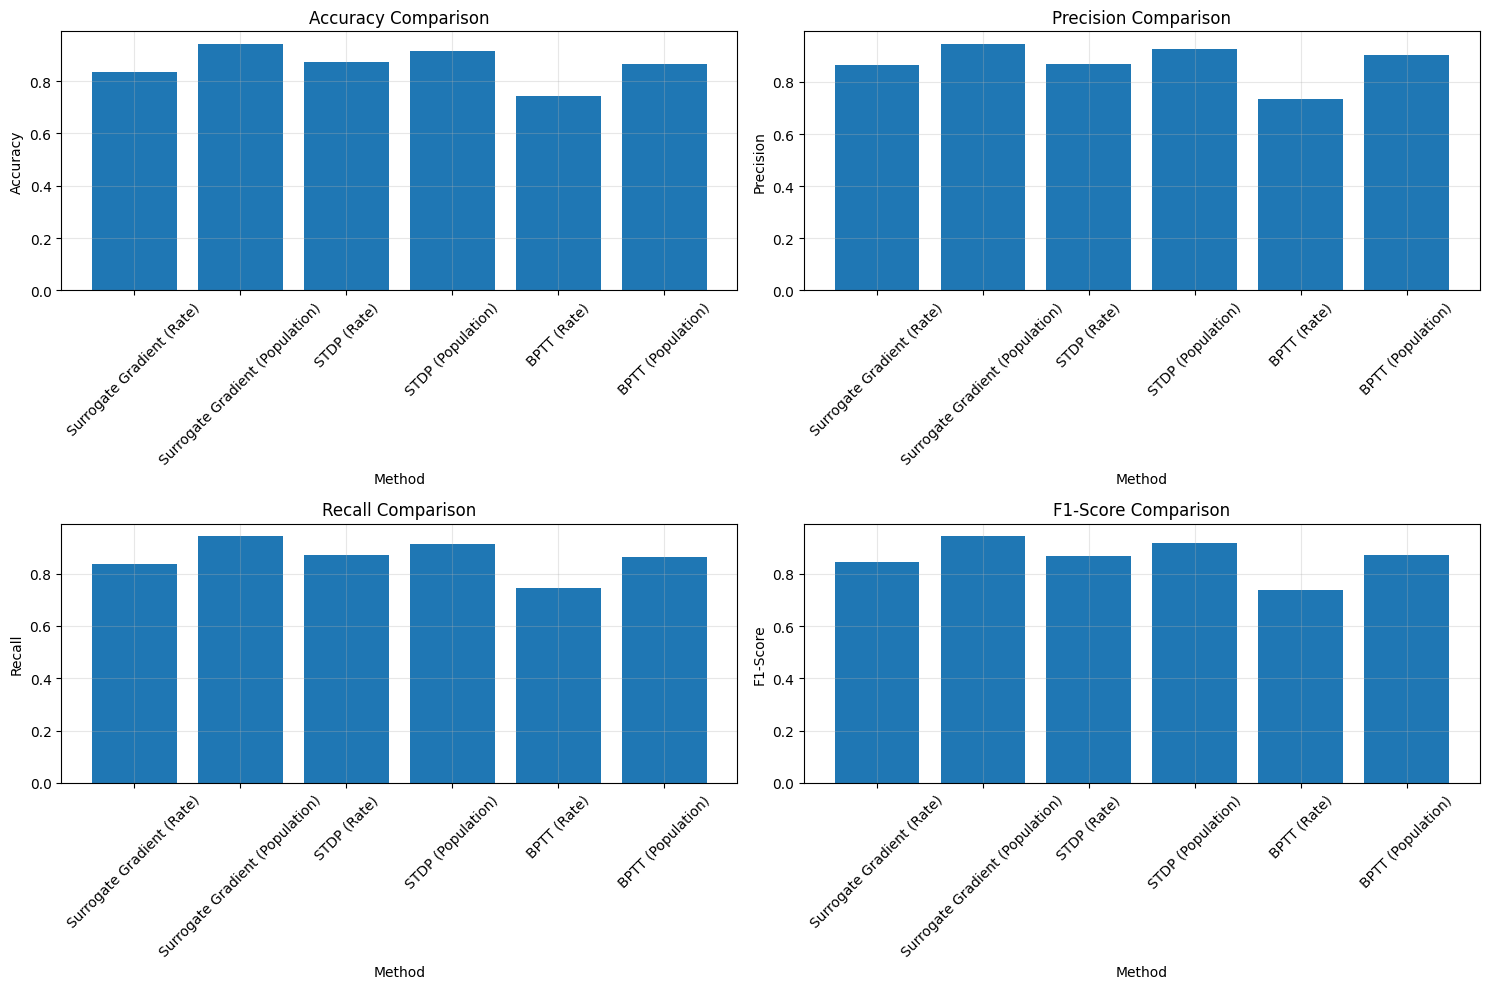

In [98]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
for idx, metric in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    ax.bar(comparison_df['Method'], comparison_df[metric])
    ax.set_xlabel('Method')
    ax.set_ylabel(metric)
    ax.set_title(f'{metric} Comparison')
    ax.tick_params(axis='x', rotation=45)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()